In [1]:
import pandas as pd, numpy as np
import argparse
import pickle
import ast
import pandas as pd
from sklearn.utils import resample
import matplotlib.pyplot as plt
import re

In [2]:
def pickle_to_res(path):
    with open(path, "rb") as f:
        raw_pickle = pickle.load(f)
    results = {}
    answer_prefix="Answer Choice "

    def extract_ans(ans_str, search_substring):
        # Split the string into lines
        lines = ans_str.split("\n")

        for line in lines:
            # Check if the line starts with the specified substring
            if line.startswith(search_substring):
                # If it does, add it to the list of extracted rows
                return line[len(search_substring) :].strip()
        return "ERROR"  # Answer not found

    for k, v in raw_pickle.items():
        if k != 'token_usage':  # Skip token_usage
            qns_idx = ast.literal_eval(k)
            for idx, qn_idx in enumerate(qns_idx):
                results[qn_idx] = extract_ans(
                    v[0], f"{answer_prefix}{idx+1}:"
                )  # We start with question 1
    
    return results



In [3]:
# Count number of 56 and malignant in test_metadata.csv
test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)
print(f'Number of 56 and malignant: {len(test_df[(test_df.skin_tone == 56) & (test_df.malignant)])}')
print(f'Number of 12 and malignant: {len(test_df[(test_df.skin_tone == 12) & (test_df.malignant)])}')

print(f'Number of 56 and benign: {len(test_df[(test_df.skin_tone == 56) &  (~test_df.malignant)])}')
print(f'Number of 12 and benign: {len(test_df[(test_df.skin_tone == 12) & (~test_df.malignant)])}')

Number of 56 and malignant: 14
Number of 12 and malignant: 12
Number of 56 and benign: 38
Number of 12 and benign: 40


In [4]:
def res_to_vec(res):
    test_df = pd.read_csv('C:/Users/sonne/Documents/Github/biasICL/ddi_test_metadata.csv', index_col=0)
    num_errors = 0
    labels, preds, race = [], [], []
    for i in test_df.itertuples():
        fst = '12' if i.skin_tone == 12 else '56'
        if (i.Index not in res) or (res[i.Index].startswith("ERROR")):
            num_errors += 1

            print(i.Index, f"answer not found")
            continue

        pred_text = res[i.Index]
        ground_truth = "B" if i.malignant == True else "A"
        labels.append(ground_truth)
        preds.append(pred_text)
        race.append(fst)
        
    print(f"In total {num_errors} errors len = {len(labels)}")
    return labels,preds,race

In [5]:
def calculate_metrics_across_replicates(exp_lists):
    """
    Calculate metrics across technical replicates
    
    Parameters:
    exp_lists: List of 3 lists, where each inner list contains experiments for one technical replicate
               Corresponding experiments should be in the same order in each replicate list
    
    Returns:
    Dictionaries containing means and standard errors for bulk, FST 1/2, and FST 5/6 metrics
    """
    # Initialize data structures for each metric type
    bulk_metrics = {'mean': [], 'stderr': []}
    fst12_metrics = {'mean': [], 'stderr': []}
    fst56_metrics = {'mean': [], 'stderr': []}
    
    # Get number of experiments in each replicate
    n_experiments = len(exp_lists[0])
    
    # For each experiment position
    for exp_idx in range(n_experiments):
        # Storage for metrics from each replicate
        bulk_replicate_metrics = []
        fst12_replicate_metrics = []
        fst56_replicate_metrics = []
        
        # Process each replicate
        for replicate_list in exp_lists:
            exp = replicate_list[exp_idx]
            results = pickle_to_res(exp)
            labels, preds, race = res_to_vec(results)
            
            # Calculate bulk metrics
            accuracy, tpr, tnr, fscore = calculate_metrics(labels, preds)
            bulk_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 1/2 metrics
            fst12_labels, fst12_preds = filter_by_race(labels, preds, race, '12')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst12_labels, fst12_preds)
            fst12_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
            
            # Calculate FST 5/6 metrics
            fst56_labels, fst56_preds = filter_by_race(labels, preds, race, '56')
            accuracy, tpr, tnr, fscore = calculate_metrics(fst56_labels, fst56_preds)
            fst56_replicate_metrics.append({
                'accuracy': accuracy,
                'tpr': tpr,
                'fscore': fscore
            })
        
        # Calculate means and standard errors across replicates
        def calc_mean_stderr(replicate_data, metric):
            values = [rep[metric] for rep in replicate_data]
            return np.mean(values), np.std(values) / np.sqrt(len(values))
        
        # Process bulk metrics
        bulk_means = {}
        bulk_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(bulk_replicate_metrics, metric)
            bulk_means[metric] = mean
            bulk_stderrs[metric] = stderr
        bulk_metrics['mean'].append(bulk_means)
        bulk_metrics['stderr'].append(bulk_stderrs)
        
        # Process FST 1/2 metrics
        fst12_means = {}
        fst12_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(fst12_replicate_metrics, metric)
            fst12_means[metric] = mean
            fst12_stderrs[metric] = stderr
        fst12_metrics['mean'].append(fst12_means)
        fst12_metrics['stderr'].append(fst12_stderrs)
        
        # Process FST 5/6 metrics
        fst56_means = {}
        fst56_stderrs = {}
        for metric in ['accuracy', 'tpr', 'fscore']:
            mean, stderr = calc_mean_stderr(fst56_replicate_metrics, metric)
            fst56_means[metric] = mean
            fst56_stderrs[metric] = stderr
        fst56_metrics['mean'].append(fst56_means)
        fst56_metrics['stderr'].append(fst56_stderrs)
    
    return bulk_metrics, fst12_metrics, fst56_metrics

def calculate_metrics(actual, predicted):
    TP = sum((a == 'B' and p == 'B') for a, p in zip(actual, predicted))
    TN = sum((a == 'A' and p == 'A') for a, p in zip(actual, predicted))
    FP = sum((a == 'A' and p == 'B') for a, p in zip(actual, predicted))
    FN = sum((a == 'B' and p == 'A') for a, p in zip(actual, predicted))
    
    precision = TP / (TP + FP) if (TP + FP) > 0 else 0
    recall = TP / (TP + FN) if (TP + FN) > 0 else 0
    
    # Calculate F1 score
    if precision + recall > 0:
        f1_score = 2 * (precision * recall) / (precision + recall)
    else:
        f1_score = 0
    
    accuracy = (TP + TN) / len(actual)
    tpr = TP / (TP + FN) if (TP + FN) > 0 else 0
    tnr = TN / (TN + FP) if (TN + FP) > 0 else 0
    
    return accuracy, tpr, tnr, f1_score



def filter_by_race(actual, predicted, race, race_value):
    filtered_actual = [a for a, r in zip(actual, race) if r == race_value]
    filtered_predicted = [p for p, r in zip(predicted, race) if r == race_value]
    return filtered_actual, filtered_predicted

In [6]:
def plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, score_type, shots, use_error_bars=False):
    """
    Plot experiment metrics with confidence intervals
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations
    score_type: string indicating the type of score being plotted ('accuracy', 'tpr', or 'fscore')
    shots: list of integers representing the number of shots for each experiment
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    # Extract means and standard deviations
    bulk_means = [m[score_type.lower()] for m in bulk_metrics['mean']]
    bulk_stds = [s[score_type.lower()] for s in bulk_metrics['stderr']]
    
    fst12_means = [m[score_type.lower()] for m in fst12_metrics['mean']]
    fst12_stds = [s[score_type.lower()] for s in fst12_metrics['stderr']]
    
    fst56_means = [m[score_type.lower()] for m in fst56_metrics['mean']]
    fst56_stds = [s[score_type.lower()] for s in fst56_metrics['stderr']]
    
    # Plot lines and confidence intervals
    if use_error_bars:
        ax1.errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                    color=line_colors[0], label=f'Aggregate {score_type}', 
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                    color=line_colors[1], label=f'FST 1/2 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
        
        ax1.errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                    color=line_colors[2], label=f'FST 5/6 {score_type}',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax1.plot(shots, bulk_means, 'o-', color=line_colors[0], label=f'Aggregate {score_type}', linewidth=2)
        ax1.fill_between(shots, 
                        np.array(bulk_means) - np.array(bulk_stds),
                        np.array(bulk_means) + np.array(bulk_stds),
                        color=line_colors[0], alpha=0.2)
        
        ax1.plot(shots, fst12_means, 's-', color=line_colors[1], label=f'FST 1/2 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst12_means) - np.array(fst12_stds),
                        np.array(fst12_means) + np.array(fst12_stds),
                        color=line_colors[1], alpha=0.2)
        
        ax1.plot(shots, fst56_means, '^-', color=line_colors[2], label=f'FST 5/6 {score_type}', linewidth=2)
        ax1.fill_between(shots,
                        np.array(fst56_means) - np.array(fst56_stds),
                        np.array(fst56_means) + np.array(fst56_stds),
                        color=line_colors[2], alpha=0.2)
    
    ax1.set_xlabel('Number of Shots')
    ax1.set_ylabel(f'{score_type}')
    ax1.set_title(f'{score_type} by Number of Shots and Skin Type')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.7)
    
    # Plot bias with confidence intervals
    biases_mean = np.array(fst12_means) - np.array(fst56_means)
    biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
    print("biases_mean", biases_mean)
    if use_error_bars:
        ax2.errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                    color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                    linewidth=2, capsize=5, capthick=1, elinewidth=1)
    else:
        ax2.plot(shots, biases_mean, 'o-', color='purple', 
                label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
        ax2.fill_between(shots,
                        biases_mean - biases_std,
                        biases_mean + biases_std,
                        color='purple', alpha=0.2)
    
    ax2.set_xlabel('Number of Shots')
    ax2.set_ylabel('Bias')
    ax2.set_title('Bias by Number of Shots')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.7)
    
    plt.tight_layout()
    plt.show()

# fst 56 only

In [7]:
def plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, title, use_error_bars=False):
    """
    Plot all experiment metrics (accuracy, TPR, F-score) in a single figure with multiple rows
    
    Parameters:
    bulk_metrics, fst12_metrics, fst56_metrics: dictionaries containing means and standard deviations/errors
    shots: list of integers representing the number of shots for each experiment
    title: string for the overall figure title
    use_error_bars: boolean indicating whether to use error bars instead of fill-between for uncertainty
    """
    # Create figure with 2 rows and 2 columns
    fig = plt.figure(figsize=(12, 9))
    
    # Create gridspec with adjusted spacing
    gs = fig.add_gridspec(2, 2, 
                         height_ratios=[1, 1], 
                         top=0.85,      # Space for title
                         bottom=0.1,    # Space for bottom labels
                         left=0.1,      # Space for left labels
                         right=0.9,     # Space for right margin
                         hspace=0.25,   # Increased vertical space between subplots
                         wspace=0.20)   # Space between columns
    
    axes = []
    for i in range(2):
        row = []
        for j in range(2):
            row.append(fig.add_subplot(gs[i, j]))
        axes.append(row)
    axes = np.array(axes)
    
    # Add title with padding
    fig.suptitle(title, fontsize=16, y=0.93)
    
    # Use custom colors for the lines
    line_colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green
    
    metrics = ['accuracy', 'fscore']
    
    for idx, score_type in enumerate(metrics):
        # Extract means and standard deviations for current metric
        bulk_means = [m[score_type] for m in bulk_metrics['mean']]
        bulk_stds = [s[score_type] for s in bulk_metrics['stderr']]
        
        fst12_means = [m[score_type] for m in fst12_metrics['mean']]
        fst12_stds = [s[score_type] for s in fst12_metrics['stderr']]
        
        fst56_means = [m[score_type] for m in fst56_metrics['mean']]
        fst56_stds = [s[score_type] for s in fst56_metrics['stderr']]
        
        # Left plot (metrics)
        if use_error_bars:
            axes[idx, 0].errorbar(shots, bulk_means, yerr=bulk_stds, fmt='o-', 
                                color=line_colors[0], label=f'Aggregate {score_type}', 
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst12_means, yerr=fst12_stds, fmt='s-',
                                color=line_colors[1], label=f'FST 1/2 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
            
            axes[idx, 0].errorbar(shots, fst56_means, yerr=fst56_stds, fmt='^-',
                                color=line_colors[2], label=f'FST 5/6 {score_type}',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 0].plot(shots, bulk_means, 'o-', color=line_colors[0], 
                            label=f'Aggregate {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots, 
                                    np.array(bulk_means) - np.array(bulk_stds),
                                    np.array(bulk_means) + np.array(bulk_stds),
                                    color=line_colors[0], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst12_means, 's-', color=line_colors[1], 
                            label=f'FST 1/2 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst12_means) - np.array(fst12_stds),
                                    np.array(fst12_means) + np.array(fst12_stds),
                                    color=line_colors[1], alpha=0.2)
            
            axes[idx, 0].plot(shots, fst56_means, '^-', color=line_colors[2], 
                            label=f'FST 5/6 {score_type}', linewidth=2)
            axes[idx, 0].fill_between(shots,
                                    np.array(fst56_means) - np.array(fst56_stds),
                                    np.array(fst56_means) + np.array(fst56_stds),
                                    color=line_colors[2], alpha=0.2)
        
        axes[idx, 0].set_xlabel('Number of Shots')
        axes[idx, 0].set_ylabel(score_type.upper())
        axes[idx, 0].set_title(f'{score_type.upper()} by Number of Shots and Skin Type')
        axes[idx, 0].legend()
        axes[idx, 0].grid(True, linestyle='--', alpha=0.7)
        
        # Right plot (bias)
        biases_mean = np.array(fst12_means) - np.array(fst56_means)
        biases_std = np.sqrt(np.array(fst12_stds)**2 + np.array(fst56_stds)**2)  # Error propagation
        
        if use_error_bars:
            axes[idx, 1].errorbar(shots, biases_mean, yerr=biases_std, fmt='o-',
                                color='purple', label=f'Bias (FST 1/2 - FST 5/6 {score_type})',
                                linewidth=2, capsize=5, capthick=1, elinewidth=1)
        else:
            axes[idx, 1].plot(shots, biases_mean, 'o-', color='purple', 
                            label=f'Bias (FST 1/2 - FST 5/6 {score_type})', linewidth=2)
            axes[idx, 1].fill_between(shots,
                                    biases_mean - biases_std,
                                    biases_mean + biases_std,
                                    color='purple', alpha=0.2)
        
        axes[idx, 1].set_xlabel('Number of Shots')
        axes[idx, 1].set_ylabel('Bias')
        axes[idx, 1].set_title(f'Bias in {score_type.upper()} by Number of Shots')
        axes[idx, 1].legend()
        axes[idx, 1].grid(True, linestyle='--', alpha=0.7)
    
    plt.show()

In [8]:
exps_rep_1 = ["C:/Users/sonne/Downloads/res1125/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_0_0_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_0_0_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_0_0_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_0_0_60_20_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_0_0_90_30_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_2 = ["C:/Users/sonne/Downloads/res1130/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_0_0_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_0_0_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_0_0_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_0_0_60_20_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_0_0_90_30_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_3 = ["C:/Users/sonne/Downloads/res1201/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_0_0_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_0_0_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_0_0_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_0_0_60_20_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_0_0_90_30_gpt-4o-2024-05-13_50.pkl",
       ]

exps_list = [exps_rep_1,exps_rep_2,exps_rep_3]

In [9]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104


In [10]:
print((bulk_metrics), (fst12_metrics), (fst56_metrics))

{'mean': [{'accuracy': np.float64(0.4775641025641026), 'tpr': np.float64(0.7051282051282052), 'fscore': np.float64(0.40306579621095745)}, {'accuracy': np.float64(0.483974358974359), 'tpr': np.float64(0.7564102564102564), 'fscore': np.float64(0.4242243036990882)}, {'accuracy': np.float64(0.6538461538461539), 'tpr': np.float64(0.5897435897435898), 'fscore': np.float64(0.46073009849100927)}, {'accuracy': np.float64(0.7403846153846154), 'tpr': np.float64(0.44871794871794873), 'fscore': np.float64(0.4634866767219708)}, {'accuracy': np.float64(0.7243589743589745), 'tpr': np.float64(0.5256410256410257), 'fscore': np.float64(0.4880952380952381)}, {'accuracy': np.float64(0.7724358974358975), 'tpr': np.float64(0.3076923076923077), 'fscore': np.float64(0.38175536047876474)}], 'stderr': [{'accuracy': np.float64(0.01831883354645541), 'tpr': np.float64(0.020935809767377578), 'fscore': np.float64(0.003088266732926818)}, {'accuracy': np.float64(0.03341131575023907), 'tpr': np.float64(0.020935809767377

2 2 2
biases_mean [-0.03205128  0.00641026 -0.02564103 -0.08333333 -0.1025641   0.01923077]


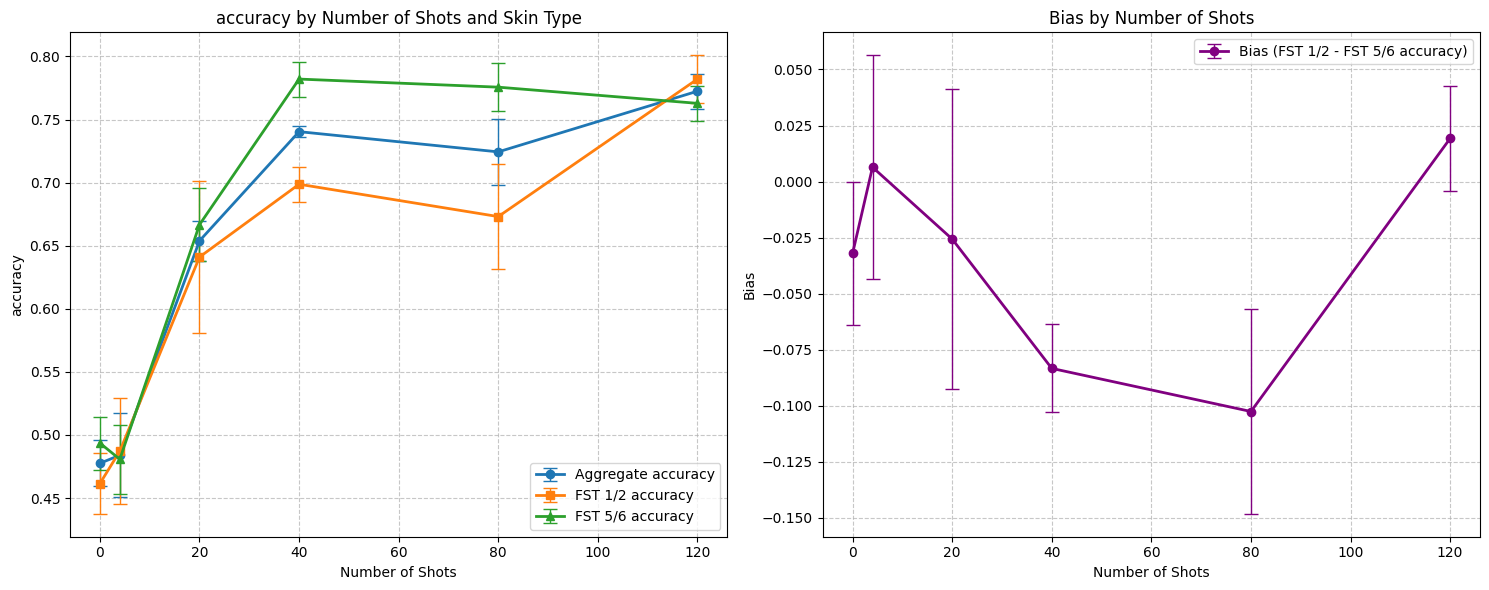

biases_mean [-0.06003302 -0.02046535 -0.20475128 -0.26777924 -0.2507712  -0.13524693]


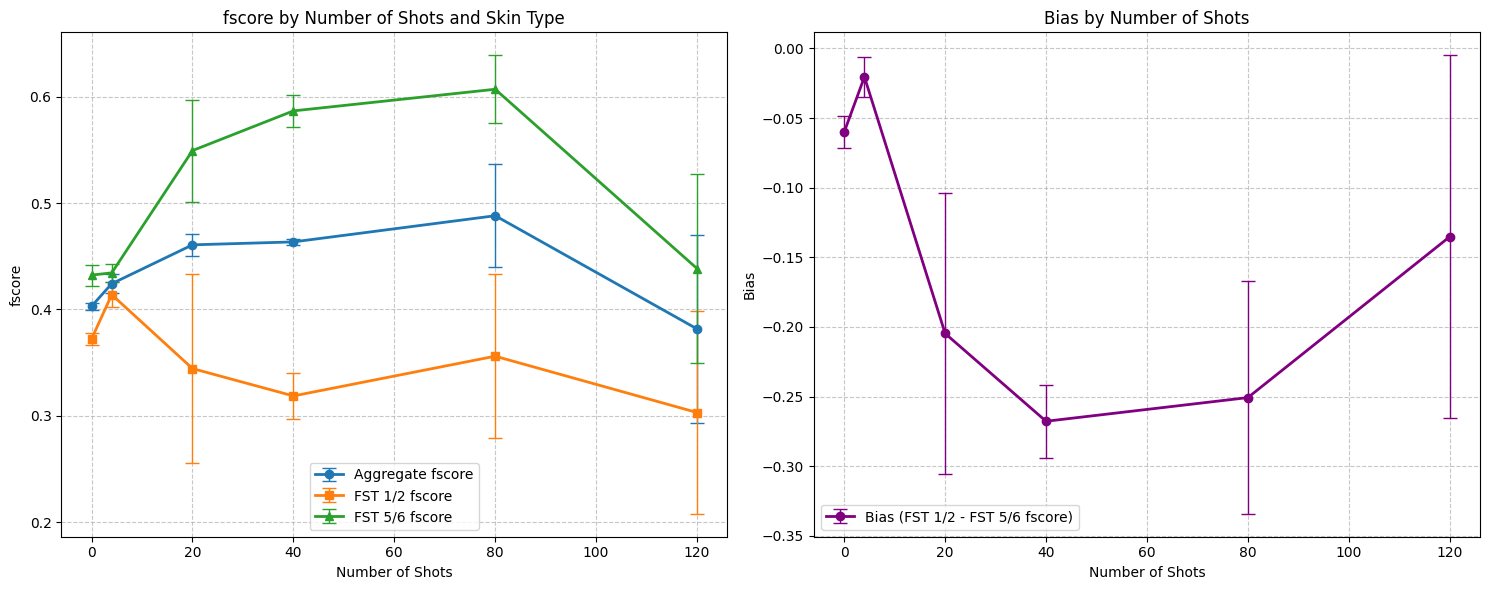

In [11]:
# Plot with confidence intervals
shots = [0, 4, 20, 40, 80, 120]
print(len(bulk_metrics), len(fst12_metrics), len(fst56_metrics))
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
# plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)

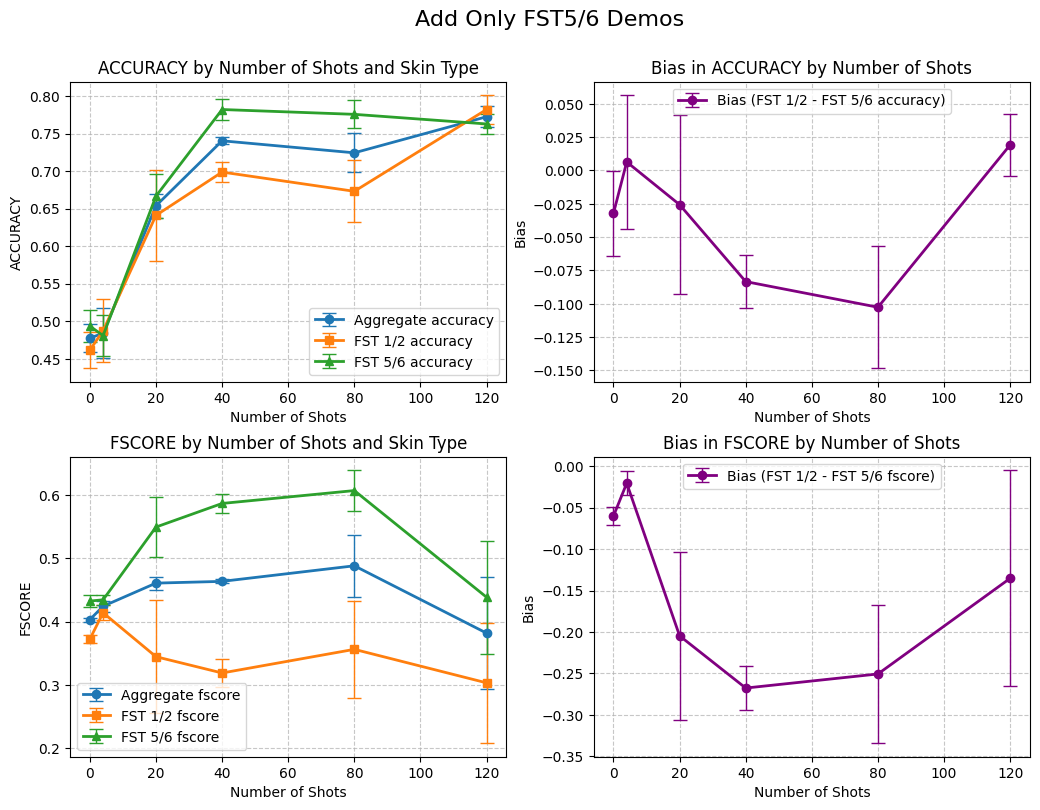

In [12]:
# Plot with confidence intervals
shots = [0, 4, 20, 40, 80, 120]
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST5/6 Demos", 
                          use_error_bars=True)

# FST 12 only 

In [13]:
exps_rep_1 = ["C:/Users/sonne/Downloads/res1125/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_3_1_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_15_5_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_30_10_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_60_20_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_90_30_0_0_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_2 = ["C:/Users/sonne/Downloads/res1130/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_3_1_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_15_5_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_30_10_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_60_20_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_90_30_0_0_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_3 = ["C:/Users/sonne/Downloads/res1201/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_3_1_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_15_5_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_30_10_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_60_20_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_90_30_0_0_gpt-4o-2024-05-13_50.pkl",
       ]

exps_list = [exps_rep_1,exps_rep_2,exps_rep_3]

In [14]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104


biases_mean [-0.03205128  0.          0.         -0.01282051 -0.02564103 -0.01923077]


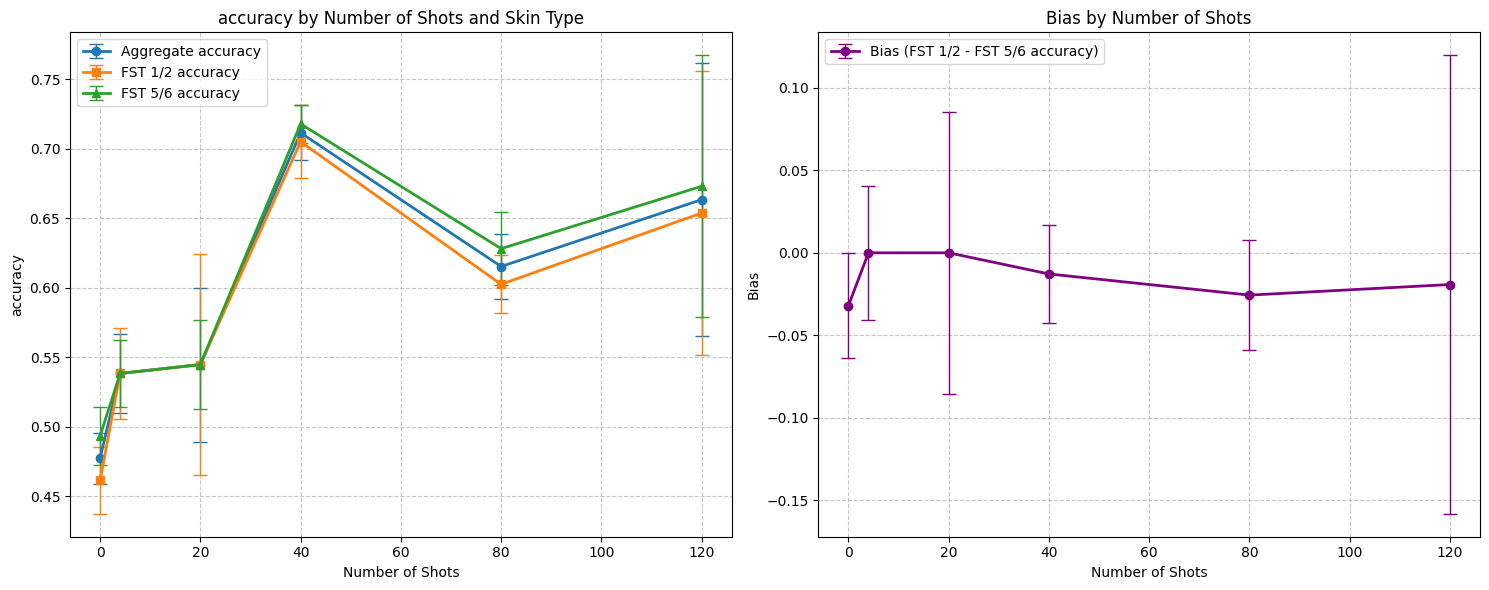

biases_mean [-0.06003302 -0.04472634 -0.06550522 -0.13596567 -0.16444709 -0.23461599]


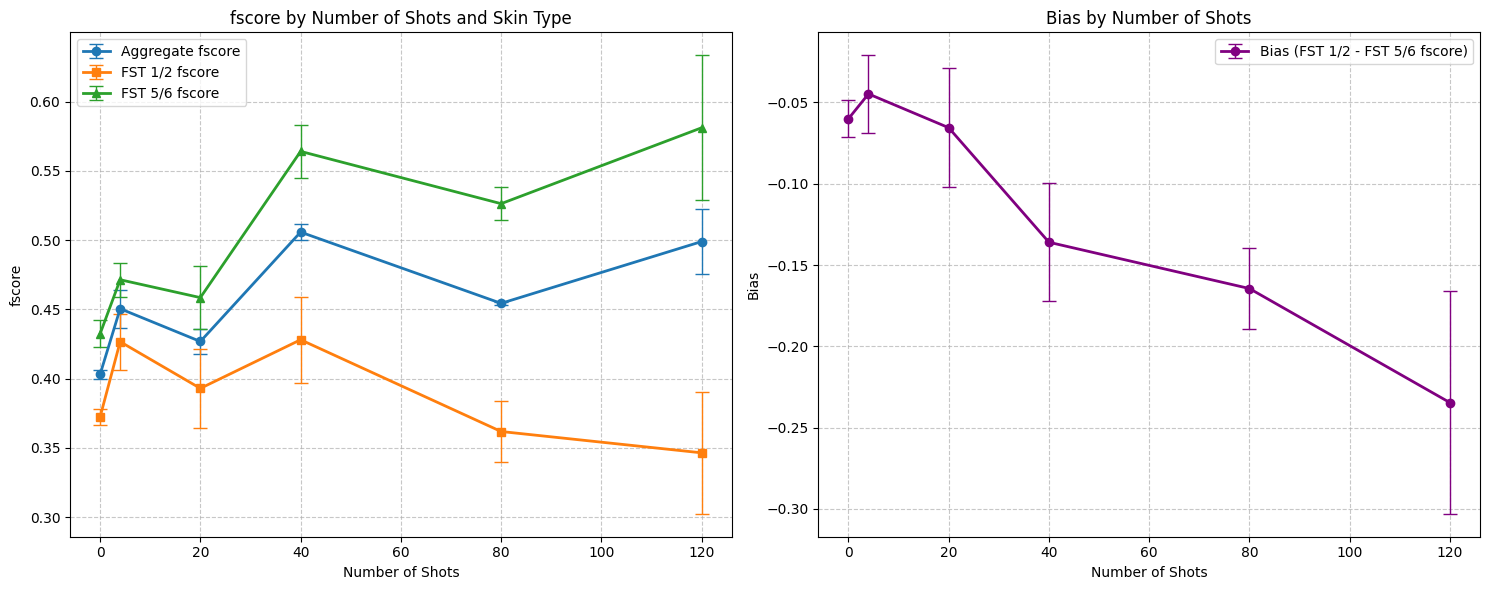

In [15]:
# Plot with confidence intervals
shots = [0, 4, 20, 40, 80, 120]
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
# plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)

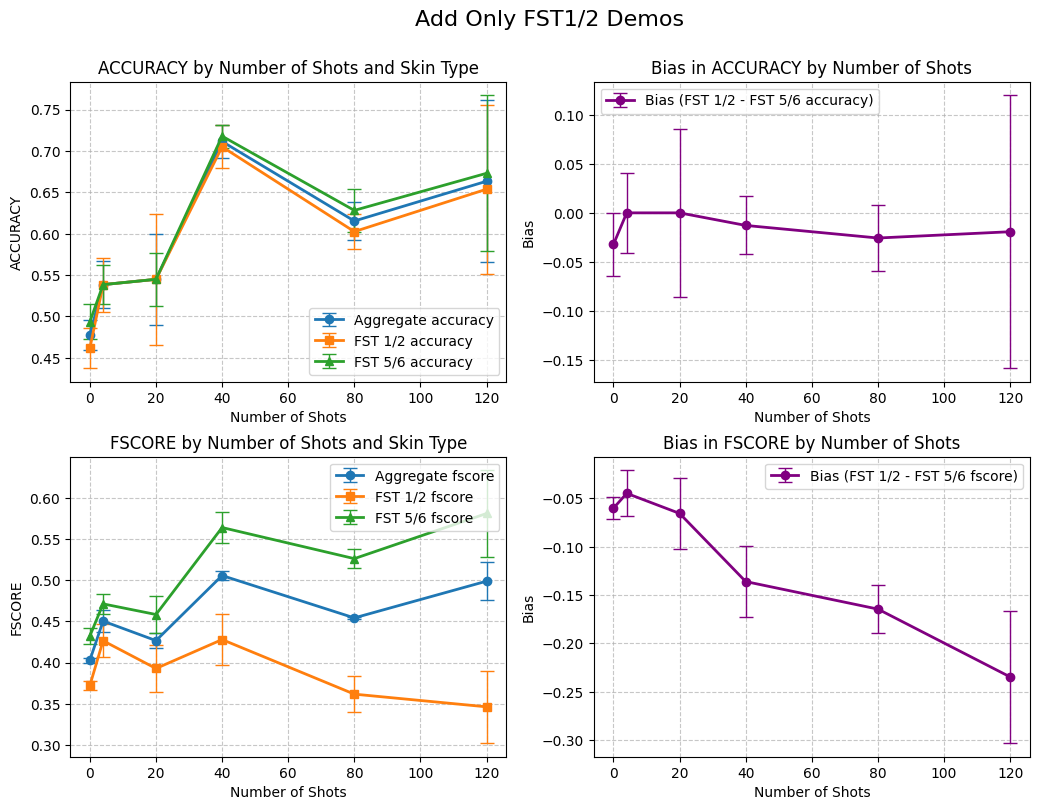

In [16]:
# Plot with confidence intervals
shots = [0, 4, 20, 40, 80, 120]
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add Only FST1/2 Demos", 
                          use_error_bars=True)

# both fst12 and fst56

In [17]:
exps_rep_1 = ["C:/Users/sonne/Downloads/res1125/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_3_1_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_15_5_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_30_10_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1125/ddi_60_20_60_20_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_2 = ["C:/Users/sonne/Downloads/res1130/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_3_1_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_15_5_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_30_10_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1130/ddi_60_20_60_20_gpt-4o-2024-05-13_50.pkl",
       ]

exps_rep_3 = ["C:/Users/sonne/Downloads/res1201/ddi_0_0_0_0_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_3_1_3_1_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_15_5_15_5_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_30_10_30_10_gpt-4o-2024-05-13_50.pkl",
              "C:/Users/sonne/Downloads/res1201/ddi_60_20_60_20_gpt-4o-2024-05-13_50.pkl",
       ]

exps_list = [exps_rep_1,exps_rep_2,exps_rep_3]

In [18]:
bulk_metrics, fst12_metrics, fst56_metrics = calculate_metrics_across_replicates(exps_list)

In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104
In total 0 errors len = 104


biases_mean [-0.03205128  0.01282051 -0.02564103 -0.04487179 -0.00641026]


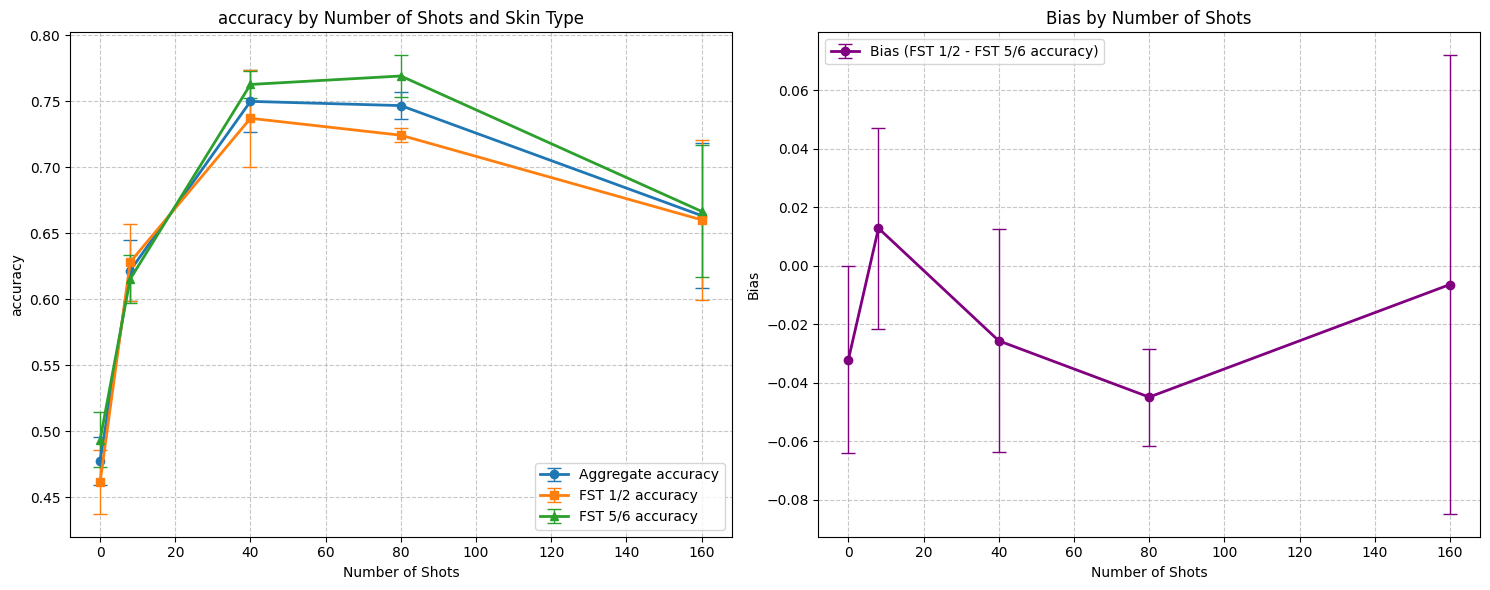

biases_mean [-0.01984127 -0.05952381 -0.11904762 -0.30555556 -0.16666667]


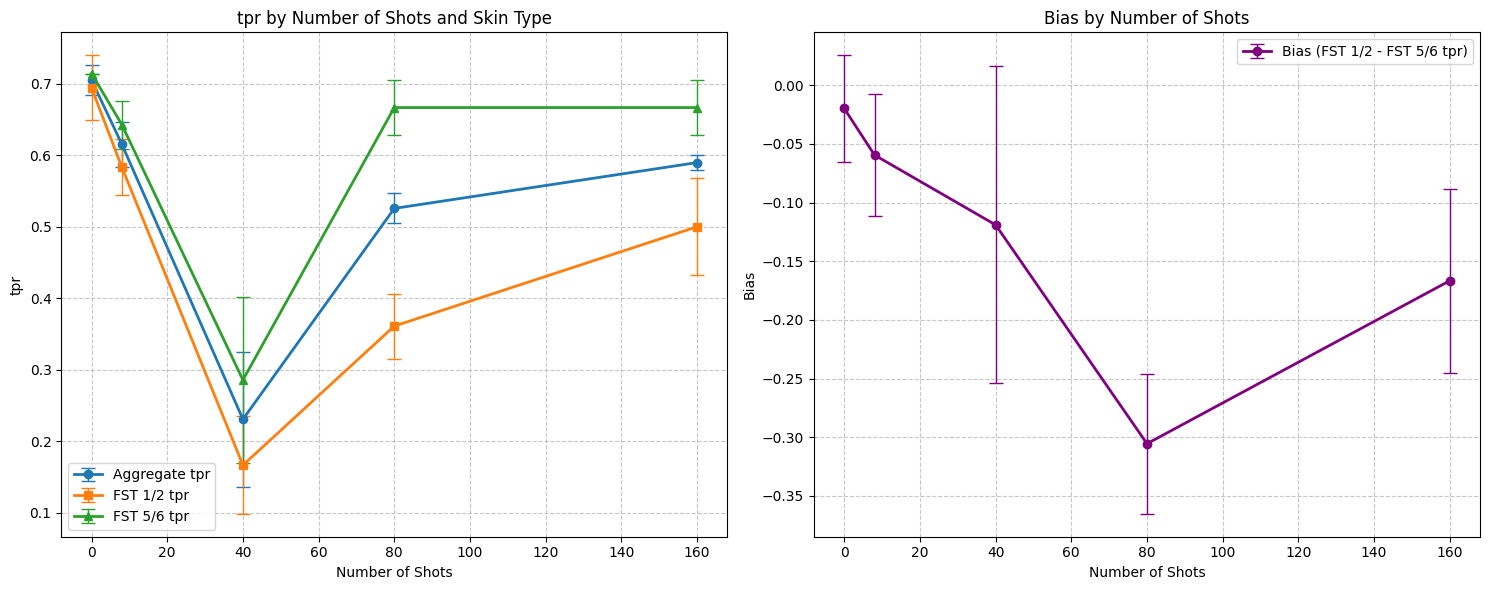

biases_mean [-0.06003302 -0.05302847 -0.12345679 -0.23566308 -0.1099774 ]


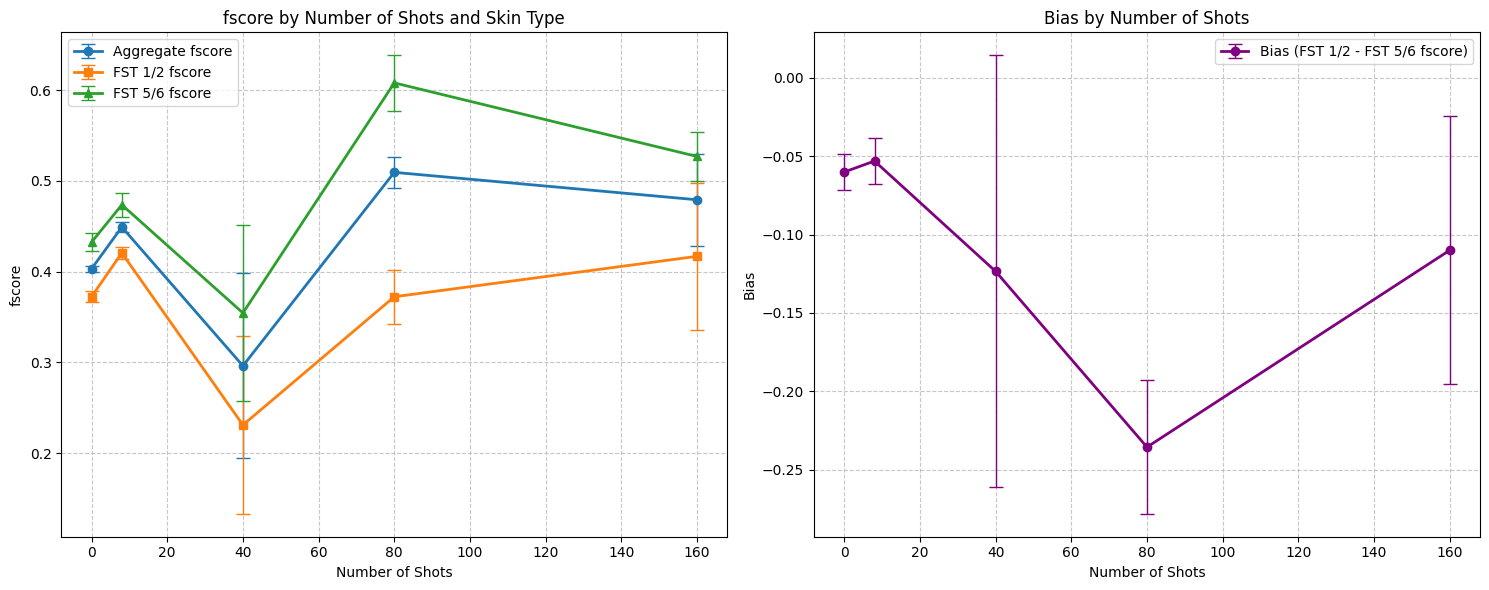

In [19]:
# Plot with confidence intervals
shots = [0, 8, 40, 80, 160]
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "accuracy", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "tpr", shots, use_error_bars=True)
plot_experiment_metrics_with_ci(bulk_metrics, fst12_metrics, fst56_metrics, "fscore", shots, use_error_bars=True)

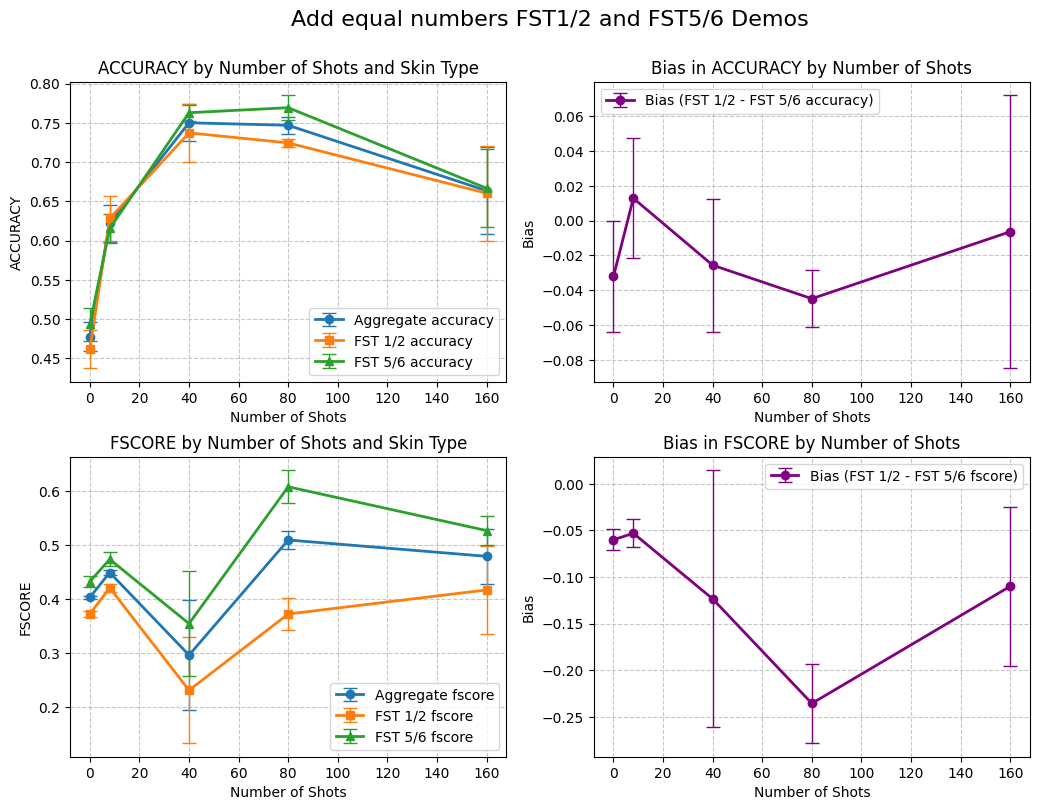

In [20]:
# Plot with confidence intervals
shots = [0, 8, 40, 80, 160]
plot_all_experiment_metrics(bulk_metrics, fst12_metrics, fst56_metrics, shots, 
                          "Add equal numbers FST1/2 and FST5/6 Demos", 
                          use_error_bars=True)

In [21]:
print(bulk_metrics, fst12_metrics, fst56_metrics)

{'mean': [{'accuracy': np.float64(0.4775641025641026), 'tpr': np.float64(0.7051282051282052), 'fscore': np.float64(0.40306579621095745)}, {'accuracy': np.float64(0.6217948717948718), 'tpr': np.float64(0.6153846153846153), 'fscore': np.float64(0.4490531255237138)}, {'accuracy': np.float64(0.75), 'tpr': np.float64(0.2307692307692308), 'fscore': np.float64(0.29610389610389615)}, {'accuracy': np.float64(0.7467948717948718), 'tpr': np.float64(0.5256410256410257), 'fscore': np.float64(0.5093285799168151)}, {'accuracy': np.float64(0.6634615384615384), 'tpr': np.float64(0.5897435897435898), 'fscore': np.float64(0.4790892334276184)}], 'stderr': [{'accuracy': np.float64(0.01831883354645541), 'tpr': np.float64(0.020935809767377578), 'fscore': np.float64(0.003088266732926818)}, {'accuracy': np.float64(0.023260193437048333), 'tpr': np.float64(0.031403714651066394), 'fscore': np.float64(0.005154989488772249)}, {'accuracy': np.float64(0.023552785988299796), 'tpr': np.float64(0.09421114395319918), 'fs

In [22]:
fst12_metrics

{'mean': [{'accuracy': np.float64(0.4615384615384615),
   'tpr': np.float64(0.6944444444444445),
   'fscore': np.float64(0.37231769412620475)},
  {'accuracy': np.float64(0.6282051282051283),
   'tpr': np.float64(0.5833333333333334),
   'fscore': np.float64(0.4205165045682287)},
  {'accuracy': np.float64(0.7371794871794872),
   'tpr': np.float64(0.16666666666666666),
   'fscore': np.float64(0.23093681917211328)},
  {'accuracy': np.float64(0.7243589743589743),
   'tpr': np.float64(0.36111111111111116),
   'fscore': np.float64(0.37222222222222223)},
  {'accuracy': np.float64(0.6602564102564102),
   'tpr': np.float64(0.5),
   'fscore': np.float64(0.4168217535153019)}],
 'stderr': [{'accuracy': np.float64(0.02398498324855092),
   'tpr': np.float64(0.04536092116265144),
   'fscore': np.float64(0.005762878361090547)},
  {'accuracy': np.float64(0.029141413882448414),
   'tpr': np.float64(0.039283710065919304),
   'fscore': np.float64(0.006983415075004407)},
  {'accuracy': np.float64(0.03663766

In [23]:
fst56_metrics

{'mean': [{'accuracy': np.float64(0.4935897435897436),
   'tpr': np.float64(0.7142857142857143),
   'fscore': np.float64(0.43235071806500375)},
  {'accuracy': np.float64(0.6153846153846154),
   'tpr': np.float64(0.6428571428571428),
   'fscore': np.float64(0.47354497354497366)},
  {'accuracy': np.float64(0.7628205128205128),
   'tpr': np.float64(0.28571428571428564),
   'fscore': np.float64(0.3543936092955701)},
  {'accuracy': np.float64(0.7692307692307692),
   'tpr': np.float64(0.6666666666666666),
   'fscore': np.float64(0.6078853046594982)},
  {'accuracy': np.float64(0.6666666666666666),
   'tpr': np.float64(0.6666666666666666),
   'fscore': np.float64(0.5267991568804576)}],
 'stderr': [{'accuracy': np.float64(0.02093580976737761),
   'tpr': np.float64(0.0),
   'fscore': np.float64(0.009874486239488741)},
  {'accuracy': np.float64(0.018130943107347388),
   'tpr': np.float64(0.0336717514850737),
   'fscore': np.float64(0.013139033885142306)},
  {'accuracy': np.float64(0.0104679048836